# **Final Notebook: Hybrid Attention MIL**

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.attention_mil_dataset import AttentionMILDataset, mil_collate_fn
from src_final.models.attention_mil import HybridAttentionMIL, run_training, run_training_unbiased
from torch.utils.data import DataLoader

In [2]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 23.00it/s]


In [3]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:40<00:00,  2.04it/s]


In [4]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_top_features['video_id'] = df_window_features['video_id'].unique()

# First Test Only With Simple Train/Validation Splitt

Once parameters adjusted move on to LOSO cross validation

In [49]:
# train val split

validation_surgeon_ids = [1]

df_top_features_train = df_top_features[~df_top_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]
df_top_features_val = df_top_features[df_top_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]

df_window_features_train = df_window_features[~df_window_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]
df_window_features_val = df_window_features[df_window_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]

### Global Feature Scaling and PCA

In [50]:
df_global_features_train = df_top_features_train.copy()
df_global_features_val = df_top_features_val.copy()

In [51]:
pca_global_features = ['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right']
additional_global_features = ['velocity_corr']

global_cols = pca_global_features + additional_global_features

df_global_features_train[global_cols] = df_global_features_train[global_cols].astype(float)
df_global_features_val[global_cols] = df_global_features_val[global_cols].astype(float)

scaler = StandardScaler()

df_global_features_train.loc[:, global_cols] = scaler.fit_transform(
    df_global_features_train.loc[:, global_cols]
)

df_global_features_val.loc[:, global_cols] = scaler.transform(
    df_global_features_val.loc[:, global_cols]
)

pca = PCA(n_components=1)

df_global_features_train.loc[:, 'global_feature_pca'] = (
    pca.fit_transform(df_global_features_train[pca_global_features])
)

df_global_features_val.loc[:, 'global_feature_pca'] = (
    pca.transform(df_global_features_val[pca_global_features])
)

global_cols = ['global_feature_pca'] + additional_global_features

### Window Feature Transformation And Scaling

In [52]:
df_window_features_train = df_window_features_train.copy()
df_window_features_val = df_window_features_val.copy()

In [53]:
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer
import pandas as pd
import numpy as np

class MILFeatureScaler:
    def __init__(self, feature_cols, log_features=None, method='robust'):
        """
        feature_cols: List of all features to be scaled.
        log_features: List of specific features to apply log(1+x) transformation to.
        method: 'robust', 'quantile', or 'standard'.
        """
        self.feature_cols = feature_cols
        self.log_features = log_features if log_features is not None else []
        self.method = method
        
        if method == 'robust':
            self.scaler = RobustScaler()
        elif method == 'quantile':
            self.scaler = QuantileTransformer(output_distribution='normal', random_state=42)
        else:
            self.scaler = StandardScaler()
            
    def _apply_log(self, df):
        """Internal helper to apply log transformation."""
        df_log = df.copy()
        for col in self.log_features:
            # np.log1p computes ln(1 + x) to handle zeros safely
            df_log[col] = np.log1p(df_log[col])
        return df_log

    def fit(self, df_all_windows):
        """Fit the scaler on training windows after log-transforming subsets."""
        # 1. Apply log transform to the subset
        df_transformed = self._apply_log(df_all_windows[self.feature_cols])
        
        # 2. Extract values and fit the scaler
        X = df_transformed.values
        self.scaler.fit(X)
        print(f"Scaler ({self.method}) fitted on {len(X)} windows with {len(self.log_features)} log-transformed features.")
        
    def transform(self, df_windows):
        """Transform windows for training or inference."""
        # 1. Apply log transform to the subset
        df_transformed = self._apply_log(df_windows[self.feature_cols])
        
        # 2. Transform the features
        X = df_transformed.values
        X_scaled = self.scaler.transform(X)
        
        # 3. Clip for numerical stability in the Neural Net
        X_scaled = np.clip(X_scaled, -5.0, 5.0)
        
        # Create a copy of the original to return, but updated with scaled values
        df_out = df_windows.copy()
        df_out[self.feature_cols] = X_scaled
        return df_out

# --- Implementation Example ---

# Define all features for the model
features_to_use = ['dim_jerk', 'curvature', 'spatial_spread', 'vel_mean', 'vel_p90', 'palm_area_cv', 'ang_vel_mean', 'path_ratio']

# Identify the skewed "physical" features for log transform
log_transform_subset = ['dim_jerk', 'spatial_spread', 'vel_mean', 'vel_p90', 'ang_vel_mean', 'path_ratio']

# Initialize
mil_scaler = MILFeatureScaler(
    feature_cols=features_to_use, 
    log_features=log_transform_subset, 
    method='robust'
)

# Fit on training data
mil_scaler.fit(df_window_features_train)

# Transform sets
train_videos_scaled = mil_scaler.transform(df_window_features_train)
val_videos_scaled = mil_scaler.transform(df_window_features_val)

Scaler (robust) fitted on 64980 windows with 6 log-transformed features.


In [10]:
df_global_features_train.head()

,Participant Number,Case_Number,GRS_Total,QRS_Overal,velocity_corr,num_reversals_Right,total_duration_Left,nmu_peaks_Right,total_path_Right,ldlj_smoothness_Left,total_angular_path_Right,video_id,global_feature_pca
0,1,1,59.25,48.50,-1.210849,-0.076799,-0.107141,-0.142609,-0.022450,-0.106897,-0.668607,"(2024-01-15_13-18-23, 1)",-0.368621
1,1,2,54.40,45.00,0.343396,-1.098450,-1.288168,-1.170081,-1.285750,-0.030397,-1.150302,"(2024-01-15_13-37-36, 1)",-2.477035
2,1,3,74.50,60.50,-0.446928,-0.160963,-0.647662,0.049827,-0.050214,0.321208,-1.149434,"(2024-01-15_14-03-23, 1)",-0.903568
3,2,1,49.25,39.25,-0.631782,2.812813,3.424252,2.970734,2.269284,-2.255259,1.507902,"(2024-01-15_14-32-45, 2)",6.258090
4,2,2,49.00,38.00,0.688665,1.454508,2.138343,1.365954,1.098966,-1.657213,0.879342,"(2024-01-15_15-05-31, 2)",3.504752


In [168]:
train_videos_scaled[features_to_use].corr()

,dim_jerk,curvature,spatial_spread,vel_mean,vel_p90,palm_area_cv,ang_vel_mean,path_ratio
dim_jerk,1.000000,0.366361,-0.593369,-0.378947,-0.466571,0.026468,0.004826,0.473338
curvature,0.366361,1.000000,-0.672657,-0.686792,-0.650067,-0.363420,-0.366287,0.015325
spatial_spread,-0.593369,-0.672657,1.000000,0.906314,0.919745,0.438299,0.533131,-0.229037
vel_mean,-0.378947,-0.686792,0.906314,1.000000,0.981072,0.583842,0.659354,0.108872
vel_p90,-0.466571,-0.650067,0.919745,0.981072,1.000000,0.549928,0.636014,0.040311
palm_area_cv,0.026468,-0.363420,0.438299,0.583842,0.549928,1.000000,0.592259,0.257128
ang_vel_mean,0.004826,-0.366287,0.533131,0.659354,0.636014,0.592259,1.000000,0.196139
path_ratio,0.473338,0.015325,-0.229037,0.108872,0.040311,0.257128,0.196139,1.000000


In [169]:
train_videos_scaled.columns

Index(['total_path', 'is_idle', 'path_ratio', 'curvature', 'vel_mean',
       'vel_p90', 'spatial_spread', 'dim_jerk', 'ang_vel_mean', 'ang_vel_std',
       'palm_area_cv', 'video_id', 'window_start_frame'],
      dtype='object')

# Generate Dataset Loaders

In [25]:
# scale the QRS score as well
score_scaler = StandardScaler()
df_global_features_train['QRS_Overal'] = score_scaler.fit_transform(
    df_global_features_train['QRS_Overal'].values.reshape(-1, 1))

df_global_features_val['QRS_Overal'] = score_scaler.transform(
    df_global_features_val['QRS_Overal'].values.reshape(-1, 1))

In [40]:
window_features = ['dim_jerk', 'curvature', 'spatial_spread', 'vel_mean', 'palm_area_cv'] + ['is_idle']

window_features = ['dim_jerk', 'spatial_spread', 'palm_area_cv', 'path_ratio'] + ['is_idle']
#window_features = ['path_ratio', 'is_idle']
#window_features = ['spatial_spread', 'palm_area_cv', 'dim_jerk', 'curvature'] + ['is_idle']

train_dataset = AttentionMILDataset(
    train_videos_scaled,
    df_global_features_train,
    window_features,
    global_cols,
    label_col='QRS_Overal'
)

val_dataset = AttentionMILDataset(
    val_videos_scaled,
    df_global_features_val,
    window_features,
    global_cols,
    label_col='QRS_Overal'
)

Preparing Bags:   0%|          | 0/80 [00:00<?, ?it/s]

Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 138.34it/s]


In [41]:
train_dataset[0]

(tensor([[ 0.4381,  0.9543, -0.1972,  0.2174,  0.0000],
         [ 0.3976,  0.4579, -0.2207,  0.7976,  0.0000],
         [ 0.3500,  0.4254, -0.2841, -0.4445,  0.0000],
         ...,
         [-0.5834,  1.1629,  0.3523, -0.0231,  0.0000],
         [-0.3767,  1.4006,  0.3490,  0.1161,  0.0000],
         [-0.1892,  1.3275,  0.3390,  0.0229,  0.0000]]),
 tensor([ 6.0312, -0.5985]),
 tensor(-1.1328),
 ('2024-01-15_14-32-45', 2))

In [42]:
train_loader = DataLoader(train_dataset, batch_size=80, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

## Attention MIL Training

In [174]:
"""model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    hidden_dim=16,
    dropout=0.1,
)

best_model, history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=1000,
    lr=5e-4,
    score_scaler=score_scaler,
    patience=100,
    verbose=True,
    #ablation='global_only'
)"""


"model = HybridAttentionMIL(\n    local_dim=len(window_features),\n    global_dim=len(global_cols),\n    hidden_dim=16,\n    dropout=0.1,\n)\n\nbest_model, history = run_training(\n    model=model,\n    train_loader=train_loader,\n    val_loader=val_loader,\n    epochs=1000,\n    lr=5e-4,\n    score_scaler=score_scaler,\n    patience=100,\n    verbose=True,\n    #ablation='global_only'\n)"

In [175]:
"""for i in range(5):
    model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    hidden_dim=16,
    dropout=0.1,
)
    
    _, _ = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=1000,
        lr=5e-4,
        score_scaler=score_scaler,
        patience=50,
        verbose=False,
        #ablation='global_only'
    )
    """

"for i in range(5):\n    model = HybridAttentionMIL(\n    local_dim=len(window_features),\n    global_dim=len(global_cols),\n    hidden_dim=16,\n    dropout=0.1,\n)\n\n    _, _ = run_training(\n        model=model,\n        train_loader=train_loader,\n        val_loader=val_loader,\n        epochs=1000,\n        lr=5e-4,\n        score_scaler=score_scaler,\n        patience=50,\n        verbose=False,\n        #ablation='global_only'\n    )\n    "

## Unbiased Training 

**No peeking at test data for model selection!**

2 approaches:

- Fix number of training epochs and adjust hyperparameters for optimal performance

- Inner nested CV and Model selection based on the performance on the held out validation data. final prediction is an average of the best model predictions.

In [45]:
model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=16,
    attention_hidden_dim=16,
    dropout=0.1,
)

_, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=750,
                      lr=2e-3,
                      score_scaler=score_scaler,
                      patience=100,
                      verbose=True,
                      avg_window=100,
                      ablation=None)

Starting training (Fixed/Train-based Stopping)...
Epoch | Train Loss | Train MAE  | Test Loss  | Test MAE (Ref)  | LR      
-------------------------------------------------------------------------------------
1     | 1.057     | 8.114     | 0.529     | 5.8216          | 2.0e-03
5     | 0.925     | 7.454     | 0.501     | 5.4462          | 2.0e-03
10    | 0.699     | 6.386     | 0.519     | 5.9666          | 2.0e-03
15    | 0.654     | 5.990     | 0.574     | 6.4416          | 2.0e-03
20    | 0.539     | 5.532     | 0.644     | 6.8494          | 2.0e-03
25    | 0.526     | 5.364     | 0.705     | 7.1620          | 2.0e-03
30    | 0.496     | 5.257     | 0.751     | 7.4003          | 2.0e-03
35    | 0.485     | 5.051     | 0.779     | 7.5665          | 2.0e-03
40    | 0.474     | 4.976     | 0.796     | 7.6857          | 2.0e-03
45    | 0.499     | 5.183     | 0.810     | 7.7877          | 2.0e-03
50    | 0.452     | 5.035     | 0.830     | 7.8968          | 2.0e-03
55    | 0.451     | 

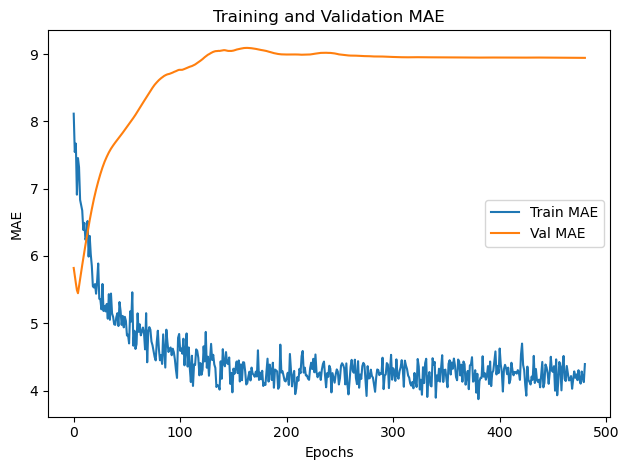

In [46]:
# plot training history
import matplotlib.pyplot as plt

def plot_training_history(history):

    # Plot training and validation MAE
    plt.figure()
    plt.plot(history['train_mae'], label='Train MAE')
    plt.plot(history['test_mae'], label='Val MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(pd.DataFrame(history))

Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 387.
Applying weight averaging over the last 100 epochs...
Averaged Model Test MAE: 6.8793 (compared to final epoch 6.9921)
Training Complete. Final Test MAE: 6.8793 at Epoch 387, Train MAE: 3.9064


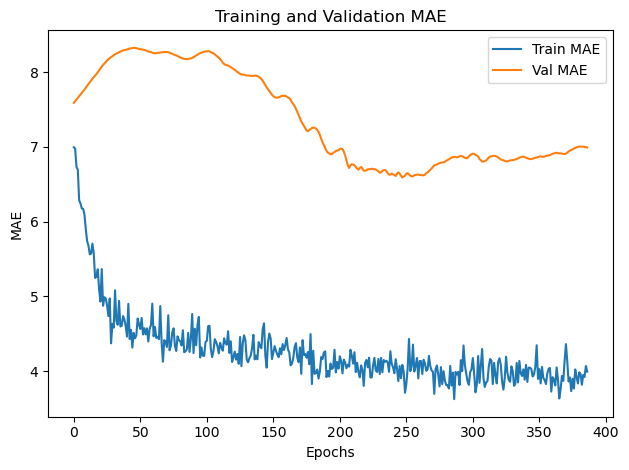

Starting training (Fixed/Train-based Stopping)...


KeyboardInterrupt: 

In [47]:
train_maes = []
val_maes = []

for i in range(5):
    model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=16,
    attention_hidden_dim=16,
    dropout=0.1,
)

    _, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=600,
                      lr=2e-3,
                      score_scaler=score_scaler,
                      patience=100,
                      verbose=False,
                      avg_window=100,
                      use_weight_averaging=True,
                      ablation=None)
    
    train_maes.append(history[-1]['train_mae'])
    val_maes.append(history[-1]['test_mae'])
    
    plot_training_history(pd.DataFrame(history))

print(f"Average Train MAE over 5 runs: {np.mean(train_maes):.4f} ± {np.std(train_maes):.4f}")
print(f"Average Val MAE over 5 runs: {np.mean(val_maes):.4f} ± {np.std(val_maes):.4f}")

# keep track of experiment outputs:

test surgeon id: 4
- window features only :  ['spatial_spread', 'palm_area_cv', 'path_ratio'] + ['is_idle']

- results (only mil feats):  
    Average Train MAE over 5 runs: 6.1710 ± 0.2017  
    Average Val MAE over 5 runs: 5.0349 ± 0.7024

- results (hybrid and with jerk feat)   
    Average Train MAE over 5 runs: 4.4393 ± 0.1462  
    Average Val MAE over 5 runs: 5.8000 ± 0.3322

test surgeon id: 5  
- results (only mil feats):
    Average Train MAE over 5 runs: 6.0400 ± 0.1681  
    Average Val MAE over 5 runs: 7.0219 ± 0.3951

test surgeon id: 6
- results (only mil feats): 
    Average Train MAE over 5 runs: 6.1914 ± 0.3458  
    Average Val MAE over 5 runs: 10.0039 ± 0.6964

- results (hybrid feats):   
    Average Train MAE over 5 runs: 4.4714 ± 0.2448  
    Average Val MAE over 5 runs: 2.2745 ± 0.4103
    
```python
mlp_hidden_dim=24,
attention_hidden_dim=16,
dropout=0.05,
patience=100,
verbose=False,
avg_window=100,
use_weight_averaging=True,
ablation='mil_only'
```

## Compute Residuals of Baseline Model

- Evaluate feature correlation to scores and residuals

- train attentionMIL on the resdiduals

In [54]:
from sklearn.linear_model import Ridge

if df_global_features_train['QRS_Overal'].mean() < 40:
    print("Scores not at original scale!!!")

ridge_model = Ridge(alpha=0.5)

ridge_model.fit(df_global_features_train[global_cols], df_global_features_train['QRS_Overal'])

train_resid = df_global_features_train['QRS_Overal'] - ridge_model.predict(df_global_features_train[global_cols])
val_resid = df_global_features_val['QRS_Overal'] - ridge_model.predict(df_global_features_val[global_cols])

print(f"Ridge Train MAE: {np.mean(np.abs(train_resid)):.4f}")
print(f"Ridge Val MAE: {np.mean(np.abs(val_resid)):.4f}")

df_global_features_train['baseline_residuals'] = train_resid.values
df_global_features_val['baseline_residuals'] = val_resid.values

Ridge Train MAE: 4.7031
Ridge Val MAE: 8.1886


In [55]:
# correlation between baseline residuals and original scores
df_global_features_train[['QRS_Overal', 'baseline_residuals']].corr()

,QRS_Overal,baseline_residuals
QRS_Overal,1.000000,0.634965
baseline_residuals,0.634965,1.000000


In [56]:
from scipy.stats import pearsonr

base_agg = train_videos_scaled[window_features + ['video_id']].groupby('video_id').agg(['mean', 'std', 'max'])

#corr of base_agg with baseline residuals
for feat in base_agg.columns:
        feat_values = base_agg[feat].values
        corr, _ = pearsonr(feat_values, df_global_features_train.set_index('video_id').loc[base_agg.index]['baseline_residuals'].values)
        print(f"Feature: {feat}, Corr: {corr:.4f}")
        


Feature: ('dim_jerk', 'mean'), Corr: 0.1602
Feature: ('dim_jerk', 'std'), Corr: 0.0041
Feature: ('dim_jerk', 'max'), Corr: 0.3218
Feature: ('spatial_spread', 'mean'), Corr: -0.2281
Feature: ('spatial_spread', 'std'), Corr: -0.1056
Feature: ('spatial_spread', 'max'), Corr: -0.0918
Feature: ('palm_area_cv', 'mean'), Corr: 0.1478
Feature: ('palm_area_cv', 'std'), Corr: 0.1129
Feature: ('palm_area_cv', 'max'), Corr: -0.0480
Feature: ('path_ratio', 'mean'), Corr: 0.1553
Feature: ('path_ratio', 'std'), Corr: 0.1082
Feature: ('path_ratio', 'max'), Corr: 0.1291
Feature: ('is_idle', 'mean'), Corr: 0.2343
Feature: ('is_idle', 'std'), Corr: 0.2227
Feature: ('is_idle', 'max'), Corr: 0.0226


In [57]:
window_features = ['spatial_spread', 'palm_area_cv', 'dim_jerk'] + ['is_idle']

train_dataset = AttentionMILDataset(
    train_videos_scaled,
    df_global_features_train,
    window_features,
    global_cols,
    label_col='baseline_residuals'
)

val_dataset = AttentionMILDataset(
    val_videos_scaled,
    df_global_features_val,
    window_features,
    global_cols,
    label_col='baseline_residuals'
)
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 159.04it/s]


Starting training (Fixed/Train-based Stopping)...
Epoch | Train Loss | Train MAE  | Test Loss  | Test MAE (Ref)  | LR      
-------------------------------------------------------------------------------------
1     | 23.307     | 4.696     | 76.945     | 8.2002          | 2.0e-03
5     | 40.569     | 4.686     | 76.997     | 8.1994          | 2.0e-03
10    | 44.899     | 4.678     | 76.952     | 8.1946          | 2.0e-03
15    | 44.389     | 4.676     | 76.923     | 8.1896          | 2.0e-03
20    | 39.440     | 4.675     | 76.804     | 8.1802          | 2.0e-03
25    | 27.246     | 4.689     | 76.541     | 8.1669          | 2.0e-03
30    | 25.389     | 4.675     | 76.338     | 8.1547          | 2.0e-03
35    | 53.727     | 4.663     | 76.337     | 8.1469          | 2.0e-03
40    | 34.691     | 4.652     | 76.131     | 8.1303          | 2.0e-03
45    | 30.934     | 4.641     | 76.061     | 8.1163          | 2.0e-03
50    | 40.499     | 4.630     | 75.653     | 8.0938          | 2.0e-0

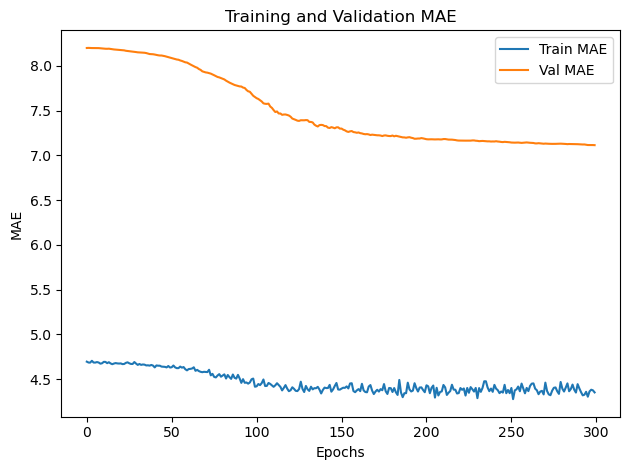

In [59]:
model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=16,
    attention_hidden_dim=24,
    dropout=0.05,
)

_, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=300,
                      lr=2e-3,
                      score_scaler=None,
                      patience=50,
                      verbose=True,
                      avg_window=50,
                      ablation='mil_only')

plot_training_history(pd.DataFrame(history))

In [60]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from tqdm import tqdm

def run_loso_mil_residual_ensemble(
    df_global,           # df_top_features
    df_windows,          # df_window_features
    window_feature_cols, # ['spatial_spread', 'palm_area_cv', 'dim_jerk', 'is_idle']
    pca_global_cols,     # The 6 metrics for PCA
    additional_global,   # ['velocity_corr']
    n_ensemble=3,        # Initializations per fold
    target_col='QRS_Overal',
    device='cpu'
):
    unique_surgeons = df_global['video_id'].apply(lambda x: int(x[1])).unique()
    
    all_final_preds = []
    all_true_scores = []
    fold_summaries = []

    # 1. Main LOSO Loop
    for surgeon_out in tqdm(unique_surgeons, desc="LOSO Folds"):
        
        # --- A. Split Data ---
        train_mask = df_global['video_id'].apply(lambda x: int(x[1])) != surgeon_out
        test_mask = df_global['video_id'].apply(lambda x: int(x[1])) == surgeon_out
        
        df_g_train = df_global[train_mask].copy()
        df_g_test = df_global[test_mask].copy()
        
        df_w_train = df_windows[df_windows['video_id'].apply(lambda x: int(x[1])) != surgeon_out].copy()
        df_w_test = df_windows[df_windows['video_id'].apply(lambda x: int(x[1])) == surgeon_out].copy()

        # --- B. Global Feature Engineering (Ridge Baseline) ---
        # 1. Scale Global features
        scaler_g = StandardScaler()
        train_scaled = scaler_g.fit_transform(df_g_train[pca_global_cols + additional_global])
        test_scaled = scaler_g.transform(df_g_test[pca_global_cols + additional_global])
        
        # 2. PCA on the subset
        pca = PCA(n_components=1)
        # Assuming PCA features are the first 6 indices
        train_pca = pca.fit_transform(train_scaled[:, :len(pca_global_cols)])
        test_pca = pca.transform(test_scaled[:, :len(pca_global_cols)])

        df_g_train['global_feature_pca'] = train_pca
        df_g_test['global_feature_pca'] = test_pca
        global_cols = ['global_feature_pca'] + additional_global
        
        # 3. Final Ridge Input: [PCA_1, velocity_corr]
        X_ridge_train = np.hstack([train_pca, train_scaled[:, len(pca_global_cols):]])
        X_ridge_test = np.hstack([test_pca, test_scaled[:, len(pca_global_cols):]])
        
        y_train = df_g_train[target_col].values
        y_test = df_g_test[target_col].values
        
        # 4. Fit Ridge and Get Residuals
        ridge = Ridge(alpha=0.5)
        ridge.fit(X_ridge_train, y_train)
        
        ridge_pred_train = ridge.predict(X_ridge_train)
        ridge_pred_test = ridge.predict(X_ridge_test)
        
        train_residuals = y_train - ridge_pred_train
        df_g_train['baseline_residuals'] = train_residuals
        test_residuals = y_test - ridge_pred_test
        df_g_test['baseline_residuals'] = test_residuals

        # --- C. MIL Feature Scaling (Local Windows) ---
        window_scale_features = window_feature_cols.copy()
        window_scale_features.remove('is_idle')  # Exclude binary feature from scaling
        mil_scaler = MILFeatureScaler(
            feature_cols=window_scale_features, 
            log_features=['dim_jerk', 'spatial_spread'], # Example subset
            method='robust'
        )
        mil_scaler.fit(df_w_train)
        w_train_scaled = mil_scaler.transform(df_w_train)
        w_test_scaled = mil_scaler.transform(df_w_test)

        # Prepare MIL Datasets
        train_ds = AttentionMILDataset(w_train_scaled, df_g_train, window_feature_cols, 
                                       global_cols, label_col='baseline_residuals')
        test_ds = AttentionMILDataset(w_test_scaled, df_g_test, window_feature_cols, 
                                      global_cols, label_col='baseline_residuals')
        
        train_loader = DataLoader(train_ds, batch_size=20, shuffle=True, collate_fn=mil_collate_fn)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

        # --- D. MIL Ensemble Training (Stage 2) ---
        fold_mil_preds = []
        fold_mil_train_preds = []
        
        for i in range(n_ensemble):
            # Re-initialize model each time
            model = HybridAttentionMIL(
                local_dim=len(window_feature_cols),
                global_dim=2, # PCA + Velocity Corr
                mlp_hidden_dim=16,
                attention_hidden_dim=24,
                dropout=0.1
            ).to(device)
            
            # Train model on residuals
            best_model, _ = run_training_unbiased(
                model, train_loader, test_loader, 
                epochs=500, lr=2e-3,
                patience=50, avg_window=50, 
                verbose=False, ablation='mil_only'
            )
            
            # Predict residual
            best_model.eval()
            with torch.no_grad():
                # Get PER-SAMPLE predictions for Train
                current_train_preds = []
                # Important: We need to keep these in order to match ridge_pred_train
                # If your train_loader has shuffle=True, this matching is HARD.
                # SUGGESTION: Use a non-shuffled loader for the final "prediction" pass.
                
                for b_bags, b_globs, _, _ in train_loader:
                    for j in range(len(b_bags)): # Changed i to j
                        p, _ = best_model(b_bags[j].to(device), b_globs[j].unsqueeze(0).to(device), ablation='mil_only')
                        current_train_preds.append(p.item())
                fold_mil_train_preds.append(np.array(current_train_preds))

                # Get PER-SAMPLE predictions for Test
                current_test_preds = []
                for b_bags, b_globs, _, _ in test_loader:
                    for j in range(len(b_bags)): # Changed i to j
                        p, _ = best_model(b_bags[j].to(device), b_globs[j].unsqueeze(0).to(device), ablation='mil_only')
                        current_test_preds.append(p.item())
                fold_mil_preds.append(np.array(current_test_preds))
        
        # Average the 3 residual predictions
        avg_mil_train_residual = np.mean(fold_mil_train_preds)
        avg_mil_residual = np.mean(fold_mil_preds)
        
        # Final prediction = Ridge Baseline + MIL Correction
        final_prediction_train = ridge_pred_train + avg_mil_train_residual
        final_prediction = ridge_pred_test + avg_mil_residual
        
        all_final_preds.extend(final_prediction)
        all_true_scores.extend(y_test)
        
        ridge_mae = mean_absolute_error(y_test, ridge_pred_test)
        fold_test_mae = mean_absolute_error(y_test, final_prediction)
        fold_train_mae = mean_absolute_error(y_train, final_prediction_train)
        fold_summaries.append({
            'Surgeon': surgeon_out,
            'Ridge_MAE': ridge_mae,
            'Test_MAE': fold_test_mae,
            'Train_MAE': fold_train_mae
        })

        print(f"\nSurgeon {surgeon_out} | Train MAE: {fold_train_mae:.4f} | Test MAE: {fold_test_mae:.4f} | Ridge MAE: {ridge_mae:.4f}\n")

    # --- E. Final Results ---
    results_df = pd.DataFrame(fold_summaries)
    overall_mae = mean_absolute_error(all_true_scores, all_final_preds)
    overall_r2 = r2_score(all_true_scores, all_final_preds)
    
    print(f"\nFinal LOSO Results:")
    print(f"Overall MAE: {overall_mae:.4f}")
    print(f"Overall R2: {overall_r2:.4f}")
    
    return results_df, all_true_scores, all_final_preds

In [61]:
window_features = ['spatial_spread', 'palm_area_cv', 'dim_jerk', 'is_idle']

results_df, true_scores, final_preds = run_loso_mil_residual_ensemble(df_top_features,
                                                                      df_window_features,
                                                                      window_features,
                                                                      pca_global_features,
                                                                      additional_global_features,
                                                                      n_ensemble=3,
                                                                      target_col='QRS_Overal',
                                                                      device='cpu'
)

LOSO Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Scaler (robust) fitted on 64980 windows with 2 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 141.30it/s]


Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 187.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.0018 (compared to final epoch 7.9879)
Training Complete. Final Test MAE: 8.0018 at Epoch 187, Train MAE: 4.4254
Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 369.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 7.8418 (compared to final epoch 7.8374)
Training Complete. Final Test MAE: 7.8418 at Epoch 369, Train MAE: 4.5093
Starting training (Fixed/Train-based Stopping)...


LOSO Folds:   4%|▎         | 1/28 [01:08<30:47, 68.43s/it]

...


[Terminated] Training converged at epoch 164.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 1.5923 (compared to final epoch 1.6071)
Training Complete. Final Test MAE: 1.5923 at Epoch 164, Train MAE: 4.6666

Surgeon 28 | Train MAE: 4.9856 | Test MAE: 1.3590 | Ridge MAE: 1.5833

Scaler (robust) fitted on 64161 windows with 2 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 86.69it/s]


Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 214.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.1573 (compared to final epoch 3.1619)
Training Complete. Final Test MAE: 3.1573 at Epoch 214, Train MAE: 4.6495
Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 224.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 2.9451 (compared to final epoch 2.9304)
Training Complete. Final Test MAE: 2.9451 at Epoch 224, Train MAE: 4.4957
Starting training (Fixed/Train-based Stopping)...


LOSO Folds: 100%|██████████| 28/28 [32:28<00:00, 69.58s/it]


[Terminated] Training converged at epoch 274.
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.9629 (compared to final epoch 3.9858)
Training Complete. Final Test MAE: 3.9629 at Epoch 274, Train MAE: 4.3992

Surgeon 29 | Train MAE: 4.8895 | Test MAE: 3.5981 | Ridge MAE: 3.4358


Final LOSO Results:
Overall MAE: 5.0584
Overall R2: 0.5412
